# Day 8: `nn.Module`, Layers & Optimizers

> **Goal:** Understand how PyTorch organises neural-network code with `nn.Module`, learn the most common layer types, and master the canonical training loop with optimizers.

---

## Why `nn.Module`?

On Days 6–7 you wrote weights as raw tensors and updated them manually. That works for 2 parameters, but real networks have **millions**. PyTorch's `nn.Module` is a lightweight base class that:

1. **Stores parameters** — every `nn.Linear`, `nn.Conv2d`, etc. you add as an attribute is automatically registered.
2. **Provides `parameters()`** — one call to iterate over all learnable tensors.
3. **Defines `forward()`** — you write the forward pass; PyTorch builds the computation graph automatically.
4. **Supports nesting** — modules can contain other modules (think LEGO bricks).

In short: **`nn.Module` is just a Python class with bookkeeping superpowers.**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.10.0


---
## 1. Your First `nn.Module`

Let's rebuild the linear model `y = wx + b` — but this time using `nn.Module`.

### Recipe
1. Subclass `nn.Module`.
2. In `__init__`, define layers (or raw `nn.Parameter`).
3. In `forward`, describe how data flows through those layers.

That's it!

In [3]:
class LinearModel(nn.Module):
    """y = w*x + b  — the simplest possible nn.Module."""

    def __init__(self):
        super().__init__()  # ALWAYS call this first
        # nn.Parameter wraps a tensor and tells Module to track it
        self.w = nn.Parameter(torch.randn(1))
        self.b = nn.Parameter(torch.randn(1))

    def forward(self, x):
        return self.w * x + self.b


model = LinearModel()
print(model)  # shows the module structure
print()

# List all learnable parameters
for name, param in model.named_parameters():
    print(f"{name:5s}  shape={param.shape}  value={param.data.item():.4f}")

LinearModel()

w      shape=torch.Size([1])  value=0.2345
b      shape=torch.Size([1])  value=0.2303


> **Key insight:** You never call `model.forward(x)` directly. Instead you call `model(x)`, which runs some bookkeeping (hooks, etc.) and *then* calls `forward`.

In [4]:
# Forward pass — use model(x), NOT model.forward(x)
x_test = torch.tensor([1.0, 2.0, 3.0])
y_pred = model(x_test)
print(f"Input:  {x_test}")
print(f"Output: {y_pred}")

Input:  tensor([1., 2., 3.])
Output: tensor([0.4648, 0.6993, 0.9337], grad_fn=<AddBackward0>)


---
## 2. `nn.Linear` — The Built-in Dense Layer

You rarely create `nn.Parameter` by hand. PyTorch provides ready-made layers.

**`nn.Linear(in_features, out_features, bias=True)`**

This computes `y = x @ W.T + b`.

| Argument | Meaning |
|---|---|
| `in_features` | Size of each input sample |
| `out_features` | Size of each output sample |
| `bias` | If `True`, adds a learnable bias |

In [5]:
linear = nn.Linear(in_features=3, out_features=2)

print("Weight shape:", linear.weight.shape)  # (out, in)
print("Bias shape:  ", linear.bias.shape)    # (out,)
print()

x = torch.randn(5, 3)          # batch of 5 samples, 3 features each
y = linear(x)                   # → shape (5, 2)
print(f"Input shape:  {x.shape}")
print(f"Output shape: {y.shape}")

Weight shape: torch.Size([2, 3])
Bias shape:   torch.Size([2])

Input shape:  torch.Size([5, 3])
Output shape: torch.Size([5, 2])


---
## 3. Stacking Layers with `nn.Sequential`

For simple feed-forward networks you can use `nn.Sequential` — it chains layers in order.

```
Input (4) → Linear(4,8) → ReLU → Linear(8,1)
```

In [6]:
seq_model = nn.Sequential(
    nn.Linear(4, 8),
    nn.ReLU(),
    nn.Linear(8, 1),
)

print(seq_model)
print(f"\nTotal parameters: {sum(p.numel() for p in seq_model.parameters())}")

# Forward pass
x = torch.randn(3, 4)
print(f"\nOutput shape: {seq_model(x).shape}")

Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=1, bias=True)
)

Total parameters: 49

Output shape: torch.Size([3, 1])


---
## 4. Building a Custom Module with Sub-modules

When your architecture needs branching, skip connections, or custom logic, subclass `nn.Module` and compose layers manually.

In [7]:
class TwoLayerNet(nn.Module):
    """A simple 2-hidden-layer network."""

    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.layer1 = nn.Linear(in_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        return x


net = TwoLayerNet(in_dim=4, hidden_dim=8, out_dim=1)
print(net)
print()
for name, p in net.named_parameters():
    print(f"{name:20s}  shape={list(p.shape)}")

TwoLayerNet(
  (layer1): Linear(in_features=4, out_features=8, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=8, out_features=1, bias=True)
)

layer1.weight         shape=[8, 4]
layer1.bias           shape=[8]
layer2.weight         shape=[1, 8]
layer2.bias           shape=[1]


---
## 5. Optimizers

On Day 6 you updated parameters manually:
```python
w = w - lr * w.grad
```

PyTorch provides **optimizers** that do this (and much more) for you.

### Common optimizers
| Optimizer | Idea |
|---|---|
| `optim.SGD` | Vanilla gradient descent (+ optional momentum) |
| `optim.Adam` | Adaptive learning rates per parameter — great default |
| `optim.AdamW` | Adam with corrected weight decay |

### How to use
```python
optimizer = optim.SGD(model.parameters(), lr=0.01)

optimizer.zero_grad()   # reset gradients
loss.backward()         # compute gradients
optimizer.step()        # update parameters
```

In [8]:
# Create an optimizer for our net
optimizer = optim.SGD(net.parameters(), lr=0.01, momentum=0.9)

print(optimizer)
print(f"\nNumber of parameter groups: {len(optimizer.param_groups)}")
print(f"Learning rate: {optimizer.param_groups[0]['lr']}")

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)

Number of parameter groups: 1
Learning rate: 0.01


---
## 6. The Canonical Training Loop 🔄

This is **the** pattern you'll use every single day from now on:

```
for epoch in range(num_epochs):
    # 1. Forward pass
    predictions = model(x)
    loss = loss_fn(predictions, y)

    # 2. Backward pass
    optimizer.zero_grad()   # ← clear old gradients!
    loss.backward()         # ← compute new gradients

    # 3. Update
    optimizer.step()        # ← adjust parameters
```

**Why `zero_grad()`?** PyTorch *accumulates* gradients by default. If you forget to zero them, gradients from the previous step add to the current ones — a very common bug!

Let's see it in action.

In [9]:
# --- Toy regression dataset ---
torch.manual_seed(42)

# True function: y = 3*x1 - 2*x2 + 1*x3 + 0.5*x4 + noise
N = 200
X = torch.randn(N, 4)
true_w = torch.tensor([3.0, -2.0, 1.0, 0.5])
Y = X @ true_w + 0.1 * torch.randn(N)  # add noise
Y = Y.unsqueeze(1)  # shape (N, 1)

print(f"X shape: {X.shape}")
print(f"Y shape: {Y.shape}")

X shape: torch.Size([200, 4])
Y shape: torch.Size([200, 1])


### The Training Loop in Action

Now we put the three-step pattern into practice: forward → backward → update. Watch the loss decrease over 300 epochs. The log-scale plot makes it easy to see both early fast progress and later fine-tuning.

In [22]:
# --- Model, loss, optimizer ---
model = TwoLayerNet(in_dim=4, hidden_dim=16, out_dim=1)
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# --- Training loop ---
num_epochs = 300
losses = []

for epoch in range(num_epochs):
    # 1. Forward
    y_pred = model(X)
    loss = loss_fn(y_pred, Y)

    # 2. Backward
    optimizer.zero_grad()
    loss.backward()

    # 3. Update
    optimizer.step()

    losses.append(loss.item())
    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d}  Loss: {loss.item():.4f}")

print(f"\nFinal loss: {losses[-1]:.4f}")

Epoch   0  Loss: 13.3830
Epoch  50  Loss: 0.3899
Epoch 100  Loss: 0.0592
Epoch 150  Loss: 0.0395
Epoch 200  Loss: 0.0303
Epoch 250  Loss: 0.0245

Final loss: 0.0199


### Training Loss Curve

The loss curve is the most important diagnostic tool. On a log scale, a well-behaved training run shows a roughly linear decrease (exponential convergence). If the loss oscillates wildly, the learning rate may be too high. If it plateaus early, the learning rate may be too low or the model too simple.

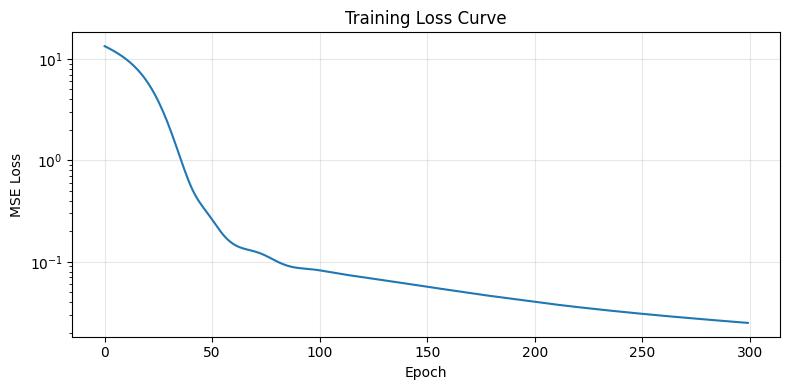

In [11]:
# Plot the loss curve
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Comparing SGD vs Adam

Let's train the same model with both optimizers and see how they differ.

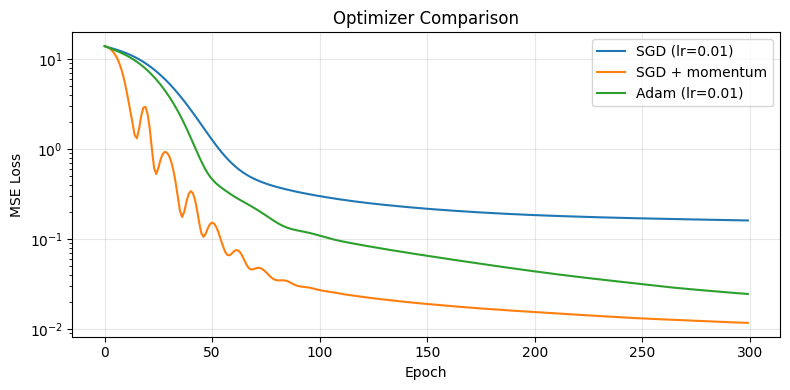

In [17]:
def train(optimizer_class, lr, epochs=300, **kwargs):
    """Train a TwoLayerNet and return loss history."""
    torch.manual_seed(0)
    model = TwoLayerNet(4, 16, 1)
    opt = optimizer_class(model.parameters(), lr=lr, **kwargs)
    loss_fn = nn.MSELoss()
    history = []
    for _ in range(epochs):
        pred = model(X)
        loss = loss_fn(pred, Y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        history.append(loss.item())
    return history


sgd_losses  = train(optim.SGD, lr=0.01)
sgdm_losses = train(optim.SGD, lr=0.01, momentum=0.9)
adam_losses  = train(optim.Adam, lr=0.01)

plt.figure(figsize=(8, 4))
plt.plot(sgd_losses,  label="SGD (lr=0.01)")
plt.plot(sgdm_losses, label="SGD + momentum")
plt.plot(adam_losses,  label="Adam (lr=0.01)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.yscale("log")
plt.legend()
plt.title("Optimizer Comparison")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### What to notice
- **SGD** can be slow, especially without momentum.
- **Momentum** accelerates convergence by "remembering" the direction of previous gradients.
- **Adam** adapts the learning rate per parameter and usually converges faster.
- Adam is a great **default choice** for most tasks.

---
## 8. `model.train()` vs `model.eval()`

Some layers behave differently during training vs evaluation (e.g., Dropout, BatchNorm). Always call:

```python
model.train()  # before training
model.eval()   # before inference / validation
```

Our current model has no such layers, but building this habit now will save you headaches later.

In [15]:
model.train()
print(f"Training mode: {model.training}")

model.eval()
print(f"Training mode: {model.training}")

# During eval, also wrap in torch.no_grad() to save memory
with torch.no_grad():
    y_eval = model(X[:5])
    print(f"\nPredictions (first 5): {y_eval.squeeze().tolist()}")

Training mode: True
Training mode: False

Predictions (first 5): [2.9620299339294434, 3.751471519470215, -6.472038269042969, -1.5090689659118652, 4.867544651031494]


---
## 9. Inspecting Your Model

A few useful utilities:

In [18]:
# Count total parameters
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total}")
print(f"Trainable parameters: {trainable}")

print("\n--- Named Parameters ---")
for name, param in model.named_parameters():
    print(f"  {name:20s} | shape {list(param.shape)} | numel {param.numel()}")

print("\n--- Named Modules ---")
for name, module in model.named_modules():
    print(f"  {name or '(root)':20s} | {module.__class__.__name__}")

Total parameters:     97
Trainable parameters: 97

--- Named Parameters ---
  layer1.weight        | shape [16, 4] | numel 64
  layer1.bias          | shape [16] | numel 16
  layer2.weight        | shape [1, 16] | numel 16
  layer2.bias          | shape [1] | numel 1

--- Named Modules ---
  (root)               | TwoLayerNet
  layer1               | Linear
  relu                 | ReLU
  layer2               | Linear


---
## 🧪 Exercises

### Exercise 1: Build a 3-layer network
Create a module with 3 linear layers (input → 32 → 16 → 1) with ReLU activations in between. Print the total parameter count.

### Exercise 2: Try different learning rates
Using the `train()` helper above, try `lr = 0.001`, `0.01`, `0.1`, and `1.0` with Adam. Plot all loss curves. Which converges fastest? Does any diverge?

### Exercise 3: What happens without `zero_grad()`?
Comment out `optimizer.zero_grad()` in the training loop and observe what happens to the loss. Why?

### Exercise 4: Freeze a layer
Set `requires_grad = False` on `layer1` parameters. Verify with `model.parameters()` that they are no longer trainable. Train the model — what happens to performance?

In [14]:
# Exercise 1: Your code here
seq_model = nn.Sequential(
    nn.Linear(4, 8),
    nn.ReLU(),
    nn.Linear(8, 6),
    nn.ReLU(),
    nn.Linear(6, 1),
)

print(seq_model)
print(f"\nTotal parameters: {sum(p.numel() for p in seq_model.parameters())}")

# Forward pass
x = torch.randn(3, 4)
print(f"\nOutput shape: {seq_model(x).shape}")

Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=6, bias=True)
  (3): ReLU()
  (4): Linear(in_features=6, out_features=1, bias=True)
)

Total parameters: 101

Output shape: torch.Size([3, 1])


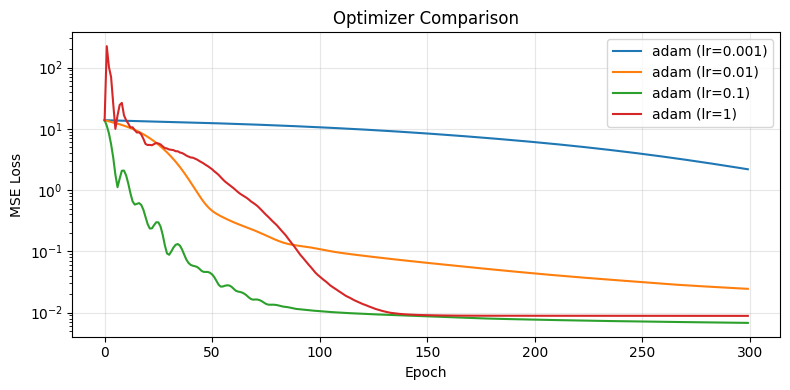

In [19]:
# Exercise 2: Your code here
adam_losses1  = train(optim.Adam, lr=0.001)
adam_losses2  = train(optim.Adam, lr=0.01)
adam_losses3  = train(optim.Adam, lr=0.1)
adam_losses4  = train(optim.Adam, lr=1)

plt.figure(figsize=(8, 4))
plt.plot(adam_losses1,  label="adam (lr=0.001)")
plt.plot(adam_losses2,  label="adam (lr=0.01)")
plt.plot(adam_losses3,  label="adam (lr=0.1)")
plt.plot(adam_losses4,  label="adam (lr=1)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.yscale("log")
plt.legend()
plt.title("Optimizer Comparison")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Exercise 3: Your code here

In [ ]:
# Exercise 4: Your code here

---
## 📝 Key Takeaways

| Concept | Summary |
|---|---|
| `nn.Module` | Base class for all neural networks — stores params & defines forward pass |
| `nn.Linear` | Fully-connected layer: `y = xW^T + b` |
| `nn.Sequential` | Chain layers in order for simple architectures |
| `model.parameters()` | Iterator over all learnable parameters |
| `optimizer.zero_grad()` | **Must** reset gradients before each backward pass |
| `loss.backward()` | Compute gradients via backprop |
| `optimizer.step()` | Update parameters using the computed gradients |
| `model.train()` / `model.eval()` | Switch between training and evaluation mode |

**Tomorrow:** We'll explore loss functions and activation functions in depth — the building blocks that determine *what* the network learns and *how* it transforms data.